### Import Important Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

### Load the Dataset and Print the Preiew of the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('data.csv')

# Preview the data
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### Data Cleaning and Feature Engineering – Preparing Categorical and Target Variables

In [3]:
# Drop only truly unnecessary columns
df.drop(columns=['date'], inplace=True)

# Drop rows with missing values (if any)
df.dropna(inplace=True)

# Bin price into categories: Low, Medium, High
price_bins = [0, 300000, 600000, df['price'].max()]
price_labels = ['Low', 'Medium', 'High']
df['price_category'] = pd.cut(df['price'], bins=price_bins, labels=price_labels)

# Drop original price column (since we're predicting the category)
df.drop(columns=['price'], inplace=True)

# Encode target variable
le = LabelEncoder()
df['price_category'] = le.fit_transform(df['price_category'])

# Encode categorical features like 'city', 'statezip', and 'street' if needed
df['city'] = df['city'].astype(str)
df['statezip'] = df['statezip'].astype(str)
df['street'] = df['street'].astype(str)

# Optional: Encode them using LabelEncoder (or one-hot if preferred later)
df['city'] = le.fit_transform(df['city'])
df['statezip'] = le.fit_transform(df['statezip'])
df['street'] = le.fit_transform(df['street'])

# Check class distribution
df['price_category'].value_counts()

,count
price_category,
2,2240
0,1378
1,933
3,49


### Exploratory Data Analysis

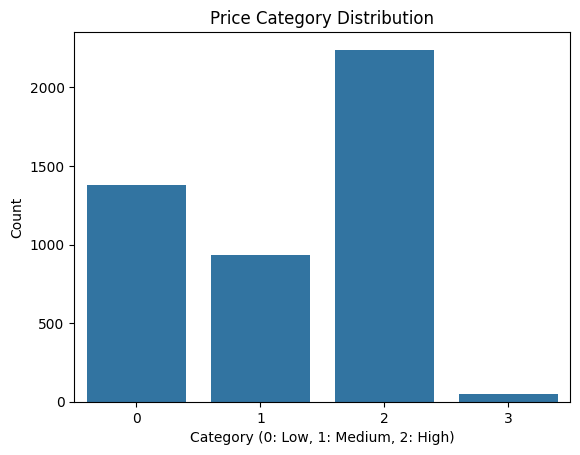

In [4]:
# Price Category Distribution
sns.countplot(x='price_category', data=df)
plt.title("Price Category Distribution")
plt.xlabel("Category (0: Low, 1: Medium, 2: High)")
plt.ylabel("Count")
plt.show()

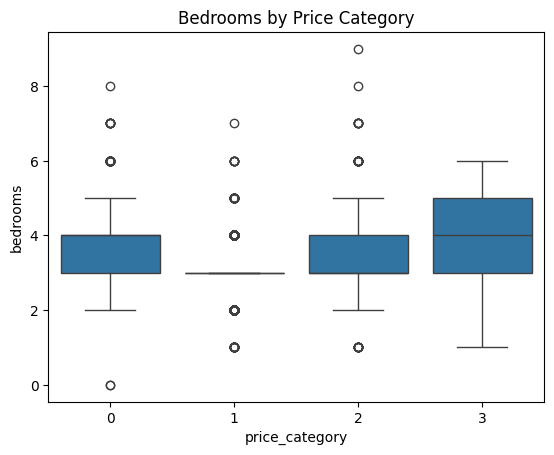

In [5]:
# Bedrooms by Price Category
sns.boxplot(x='price_category', y='bedrooms', data=df)
plt.title("Bedrooms by Price Category")
plt.show()

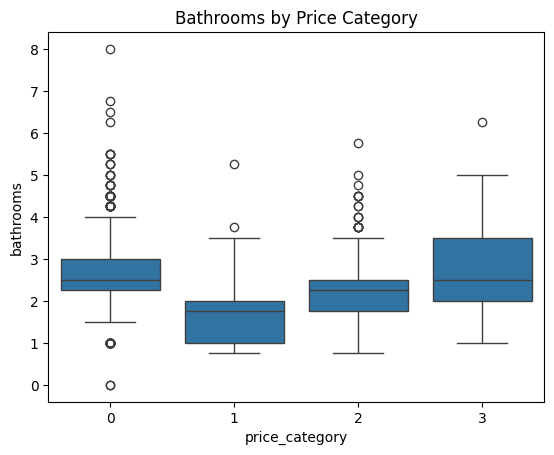

In [6]:
# Bathrooms by Price Category
sns.boxplot(x='price_category', y='bathrooms', data=df)
plt.title("Bathrooms by Price Category")
plt.show()

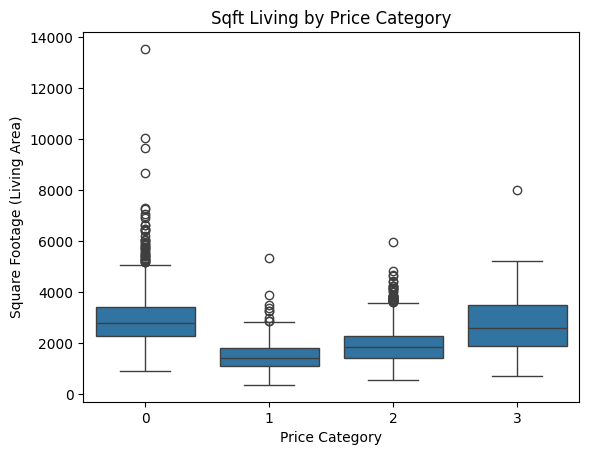

In [7]:
# Sqft Living by Price Category (simplified)
sns.boxplot(x='price_category', y='sqft_living', data=df)
plt.title("Sqft Living by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Square Footage (Living Area)")
plt.show()

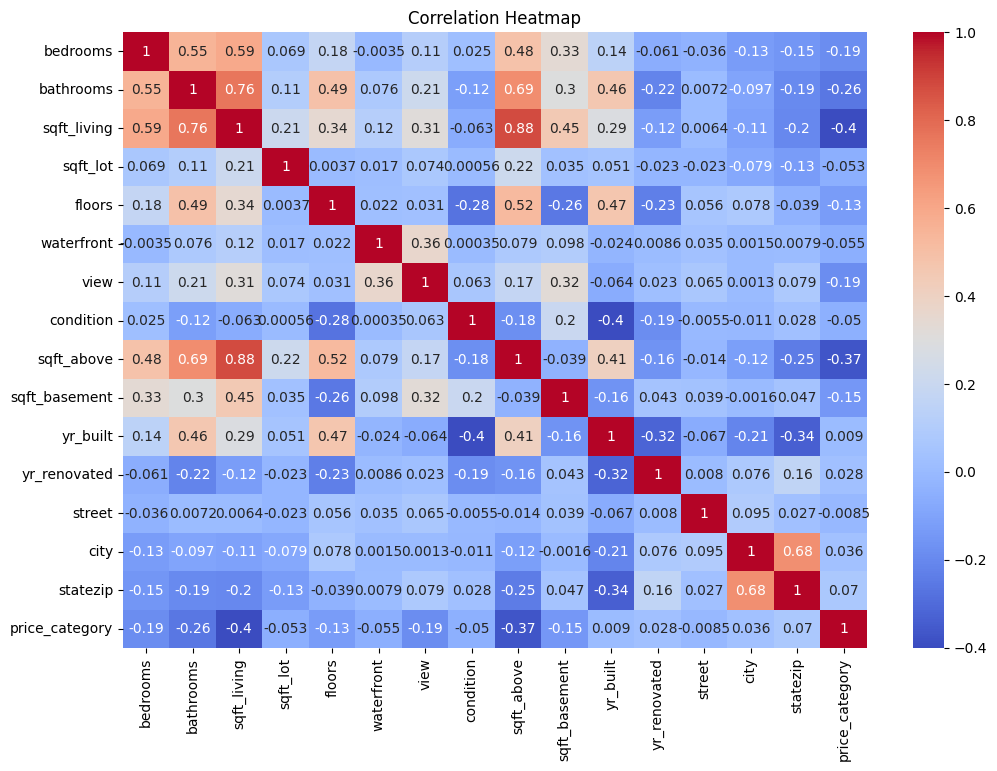

In [8]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])  # Select only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Preprocessing – Encoding Categorical Features and Scaling Data

In [9]:
from sklearn.preprocessing import LabelEncoder

# Remove rare class (class 3 if present)
df = df[df['price_category'] != 3]

# Encode string columns to numeric using LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoders if needed later

# Features & target
X = df.drop('price_category', axis=1)
y = df['price_category']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<ipython-input-9-7942db857f0a>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])


### Apply SMOTE to balance class distribution

In [10]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

<ipython-input-11-fa5031fe3b8c>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _ = sns.countplot(data=resampled_df, x='price_category', palette='viridis')  # Suppress auto display


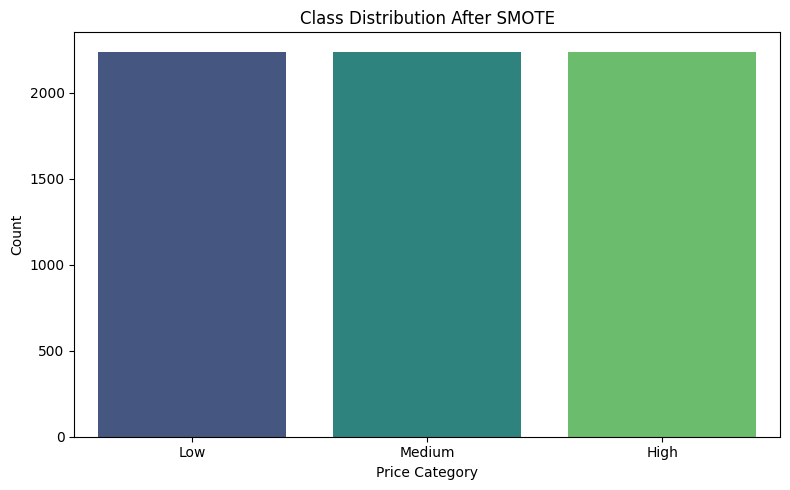

In [11]:
# Create a DataFrame to hold the resampled target values
resampled_df = pd.DataFrame({'price_category': y_resampled})

# Plot the distribution of the resampled classes
plt.figure(figsize=(8, 5))
_ = sns.countplot(data=resampled_df, x='price_category', palette='viridis')  # Suppress auto display
plt.title('Class Distribution After SMOTE')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'])
plt.tight_layout()
plt.show()

### Split data into training and testing sets

In [12]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

### Hyperparameter tuning using GridSearchCV for KNN

In [13]:
# Grid search for best KNN
param_grid = {
    'n_neighbors': list(range(3, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                         14, 15],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

### KNN model prediction and evaluation

In [14]:
# Best model and predictions
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

# Evaluation
print("Best KNN Params:", grid.best_params_)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred))

Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
KNN Accuracy: 0.8169642857142857

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       453
           1       0.78      0.94      0.86       437
           2       0.84      0.61      0.71       454

    accuracy                           0.82      1344
   macro avg       0.82      0.82      0.81      1344
weighted avg       0.82      0.82      0.81      1344



### Confusion Matrix of the KNN Classifier

<Figure size 800x600 with 0 Axes>

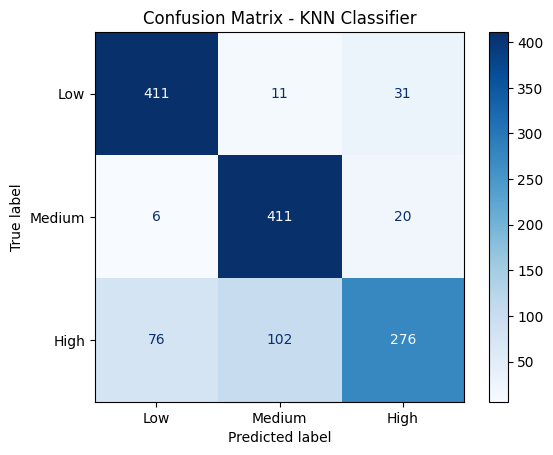

In [15]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define correct labels (since we dropped class 3)
class_names = ['Low', 'Medium', 'High']  # Corresponding to 0, 1, 2

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - KNN Classifier")
plt.grid(False)
plt.show()

### Evaluation of the Random Forest Classifier Model

In [16]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Random Forest Report
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       453
           1       0.89      0.91      0.90       437
           2       0.82      0.75      0.78       454

    accuracy                           0.85      1344
   macro avg       0.85      0.85      0.85      1344
weighted avg       0.85      0.85      0.85      1344



### Plot of Confusion Matrix fo the Random Forest

<Figure size 800x600 with 0 Axes>

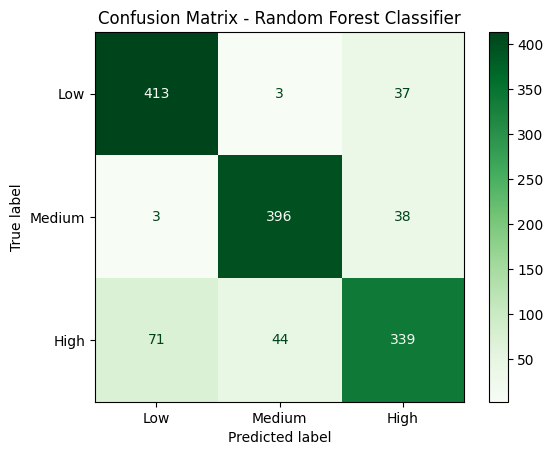

In [17]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Class names used during training (corresponding to 0, 1, 2)
class_names = ['Low', 'Medium', 'High']

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names)
disp_rf.plot(cmap='Greens', values_format='d')
plt.title("Confusion Matrix - Random Forest Classifier")
plt.grid(False)
plt.show()

### Classification Report and Confusion Matrix for Neural Network

In [22]:
# Initialize and train
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# Predict and evaluate
y_pred_mlp = mlp.predict(X_test)

print("Neural Network (MLP) Classification Report:\n", classification_report(y_test, y_pred_mlp))

Neural Network (MLP) Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       453
           1       0.80      0.88      0.84       437
           2       0.76      0.64      0.69       454

    accuracy                           0.80      1344
   macro avg       0.80      0.80      0.79      1344
weighted avg       0.80      0.80      0.79      1344



<Figure size 800x600 with 0 Axes>

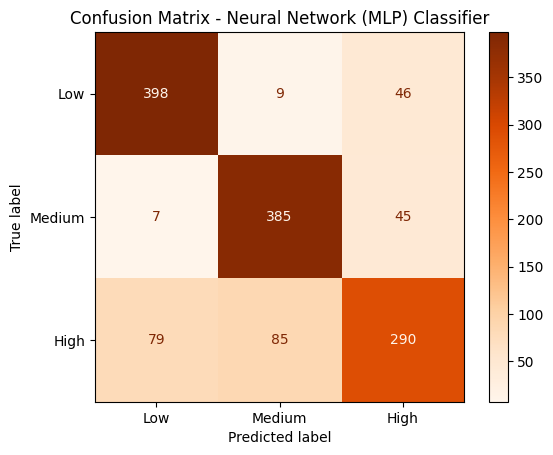

In [23]:
# Confusion matrix for MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

# Class labels
class_names = ['Low', 'Medium', 'High']

# Plotting
plt.figure(figsize=(8, 6))
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=class_names)
disp_mlp.plot(cmap='Oranges', values_format='d')
plt.title("Confusion Matrix - Neural Network (MLP) Classifier")
plt.grid(False)
plt.show()

### Comparison Plot

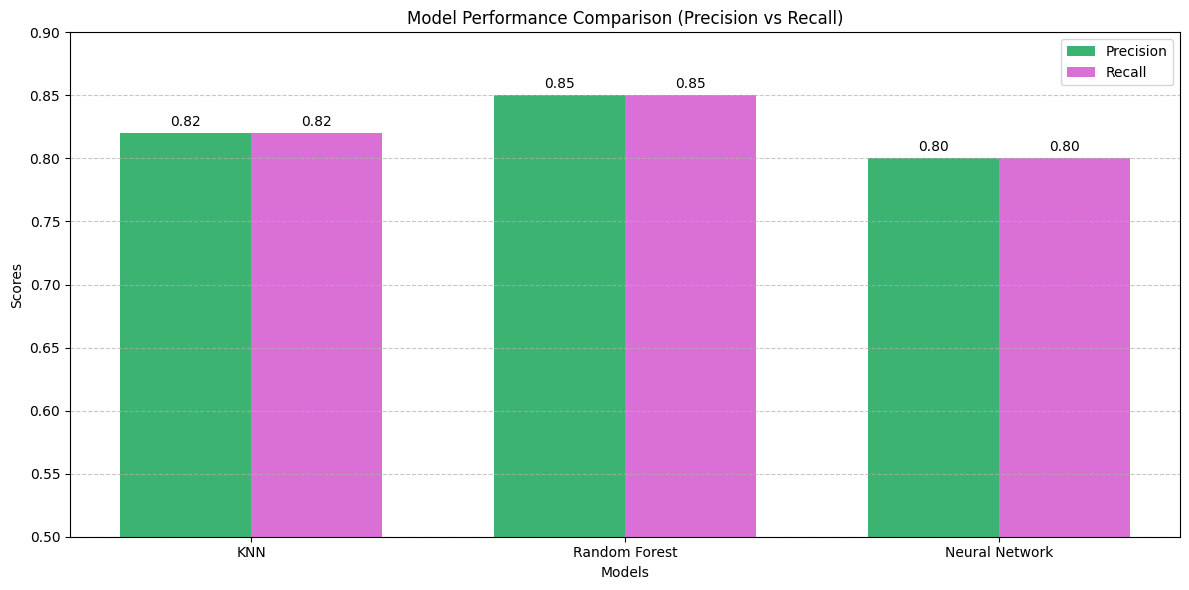

In [24]:
# Define model names
models = ['KNN', 'Random Forest', 'Neural Network']

# Define precision and recall values (weighted avg)
precision_scores = [0.82, 0.85, 0.80]  # KNN, Random Forest, Neural Network
recall_scores = [0.82, 0.85, 0.80]    # KNN, Random Forest, Neural Network

# Plotting
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, precision_scores, width, label='Precision', color='mediumseagreen')
bars2 = ax.bar(x + width/2, recall_scores, width, label='Recall', color='orchid')

# Add text labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

# Chart details
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison (Precision vs Recall)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0.5, 0.9])
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<ipython-input-25-62ee23d81135>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=accuracy_df, x='Model', y='Accuracy', palette='mako')


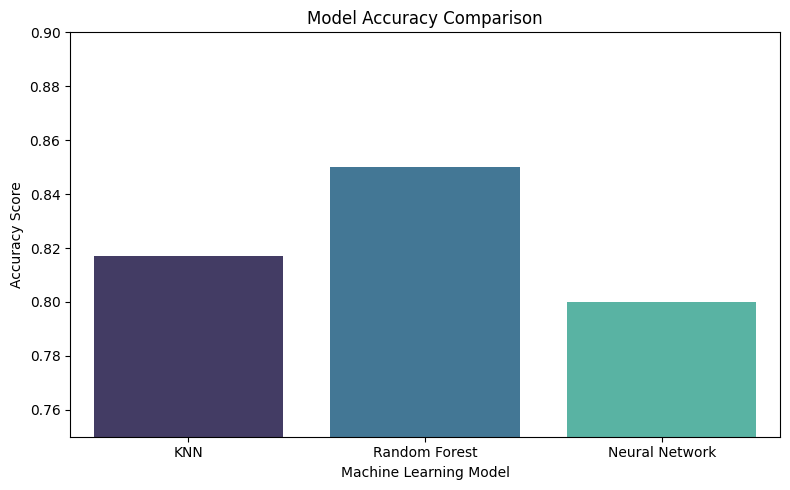

In [25]:
# Accuracy scores from the outputs
model_names = ['KNN', 'Random Forest', 'Neural Network']
accuracies = [0.82, 0.85, 0.80]

# Create DataFrame for plotting
accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=accuracy_df, x='Model', y='Accuracy', palette='mako')
plt.title('Model Accuracy Comparison')
plt.ylim(0.75, 0.90)
plt.ylabel('Accuracy Score')
plt.xlabel('Machine Learning Model')
plt.tight_layout()
plt.show()